# Data prep

In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df_polarizability = pd.read_csv('../polygraphpy/data/polarizability_data.csv')
df_original = pd.read_csv('../polygraphpy/data/original_dataset.csv')
df_ga_output = pd.read_csv('../polygraphpy/data/ga_output/generated_molecules.csv')
df_gpt_output = pd.read_csv('../polygraphpy/data/generative_output/generated_molecules.csv')

df_gpt_output = df_gpt_output.rename(columns={'smiles_A': 'smiles'})
df_polarizability = df_polarizability[df_polarizability['chain_size'] == 0]

scaler = MinMaxScaler()
scaler.fit(df_polarizability[['static_polarizability']])

df_ga_output['static_polarizability_pred_original'] = scaler.inverse_transform(df_ga_output[['static_polarizability']])
df_polarizability_aux = df_polarizability[['smiles_A', 'static_polarizability']].rename(columns={'smiles_A': 'smiles'})

df_original = df_original[['polararea', 'mw', 'smiles', 'xlogp', 'complexity', 'heavycnt', 'rotbonds']].merge(df_polarizability_aux, on='smiles')

In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolDescriptors

def get_precise_vdw_volume(smiles):
    if pd.isna(smiles):
        return None
        
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
        
    mol = Chem.AddHs(mol)
    
    params = AllChem.ETKDG()
    params.randomSeed = 42 
    success = AllChem.EmbedMolecule(mol, params)
    
    if success != 0:
        pass
        
    try:
        AllChem.UFFOptimizeMolecule(mol)
    except:
        pass
        
    try:
        dclv = rdMolDescriptors.DoubleCubicLatticeVolume(mol)
        return dclv.GetVDWVolume()
    except:
        pass

#df_ga_output['vdw_volume'] = df_ga_output['smiles'].apply(get_precise_vdw_volume)
#df_gpt_output['vdw_volume'] = df_gpt_output['smiles'].apply(get_precise_vdw_volume)
df_original['vdw_volume'] = df_original['smiles'].apply(get_precise_vdw_volume)

[10:47:36] UFFTYPER: Unrecognized charge state for atom: 0
[10:47:36] UFFTYPER: Unrecognized atom type: Zn+2 (0)
[10:47:36] UFFTYPER: Unrecognized charge state for atom: 5
[10:47:36] UFFTYPER: Unrecognized atom type: Zn+2 (5)
[10:47:38] UFFTYPER: Warning: hybridization set to SP3 for atom 7
[10:47:38] UFFTYPER: Warning: hybridization set to SP3 for atom 7
[10:47:47] UFFTYPER: Unrecognized charge state for atom: 0
[10:47:47] UFFTYPER: Unrecognized atom type: Zn+2 (0)
[10:47:47] UFFTYPER: Unrecognized charge state for atom: 11
[10:47:47] UFFTYPER: Unrecognized atom type: Zn+2 (11)
[10:48:23] UFFTYPER: Warning: hybridization set to SP3 for atom 4
[10:48:23] UFFTYPER: Warning: hybridization set to SP3 for atom 4
[10:49:28] UFFTYPER: Warning: hybridization set to SP3 for atom 5
[10:49:28] UFFTYPER: Warning: hybridization set to SP3 for atom 5
[10:49:59] UFFTYPER: Unrecognized charge state for atom: 11
[10:49:59] UFFTYPER: Unrecognized charge state for atom: 11


In [4]:
#df_ga_output.to_csv('df_ga_output.csv', index=False)
#df_gpt_output.to_csv('df_gpt_output.csv', index=False)
df_original.to_csv('df_original_.csv', index=False)

# Refractive index

In [1]:
import pandas as pd
import numpy as np

def calculate_refractive_index(df, pol_col='static_polarizability_pred_original', vol_col='vdw_volume'):
    """
    Computes Lorentz-Lorentz refractive index.
    
    Formula:
      n_o^2 = [1 + 2 * A] / [1 - A]
      where A = (4*pi/3) * N * alpha
            alpha = static_polarizability * 0.14818471
            N = K / vdw_volume
            K = 0.68
    """
    K = 0.68
    PI = np.pi
    
    N = K / df[vol_col]
    
    alpha = df[pol_col] * 0.14818471
    
    A = (4 * PI / 3) * N * alpha
    
    n_squared = (1 + 2 * A) / (1 - A)
    
    n_o = np.sqrt(n_squared)
    
    return n_o

df_ga_output = pd.read_csv('df_ga_output.csv')
df_gpt_output = pd.read_csv('df_gpt_output.csv')
df_original = pd.read_csv('df_original_.csv')

print(f'{len(df_ga_output)}, {len(df_gpt_output)}, {len(df_original)}')

df_gpt_output = df_gpt_output[df_gpt_output['error'] <= 0.22]

df_ga_output['refractive_index'] = calculate_refractive_index(df_ga_output, pol_col='static_polarizability_pred_original', vol_col='vdw_volume')
df_gpt_output['refractive_index'] = calculate_refractive_index(df_gpt_output, pol_col='static_polarizability_pred_original', vol_col='vdw_volume')
df_original['refractive_index'] = calculate_refractive_index(df_original, pol_col='static_polarizability', vol_col='vdw_volume')
df_ga_output = df_ga_output.drop_duplicates(subset='smiles')
df_gpt_output = df_gpt_output.drop_duplicates(subset='smiles')

### FILTERING REFRACTIVE INDEX OUTLIERS

df_ga_output = df_ga_output[df_ga_output['refractive_index'] <= 1.7].reset_index(drop=True)
df_gpt_output = df_gpt_output[df_gpt_output['refractive_index'] <= 1.7].reset_index(drop=True)
df_original = df_original[df_original['refractive_index'] <= 1.7].reset_index(drop=True)

print(f'{len(df_ga_output)}, {len(df_gpt_output)}, {len(df_original)}')

10000, 657, 9208
3025, 115, 9057


/home/jgduarte/Documents/RA/Projects/3M/PolyGraphPy/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/jgduarte/Documents/RA/Projects/3M/PolyGraphPy/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


# plots

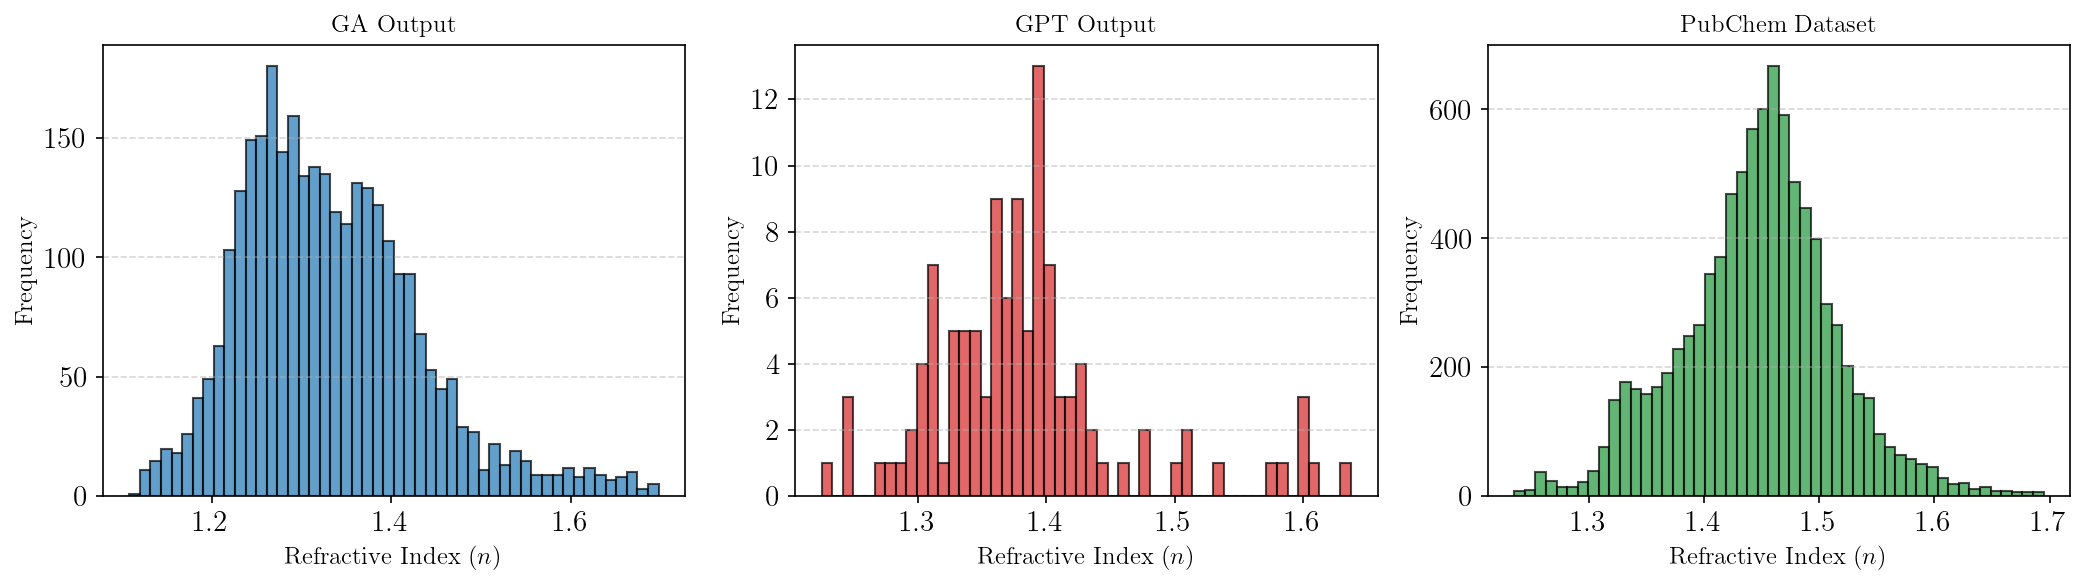

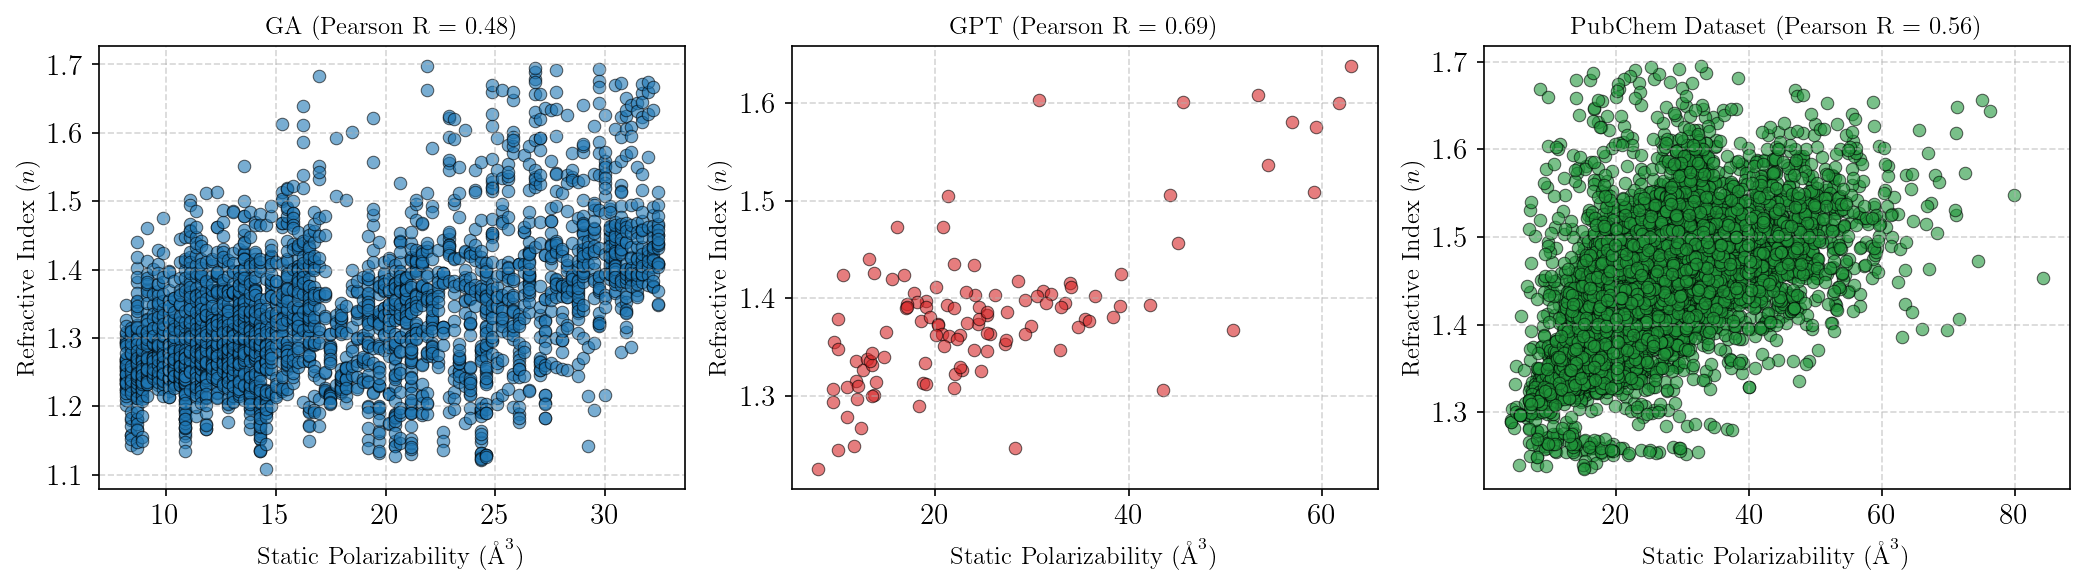

In [2]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": True,                # requires a LaTeX install
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,                 # embed text as text in PDFs
})

# Define a consistent style/color scheme manually since we aren't using seaborn
GA_COLOR = '#1f77b4'  # Standard matplotlib blue
GPT_COLOR = '#d62728' # Standard matplotlib red
ORIGINAL_COLOR = "#20963a" # Standard matplotlib red
ALPHA_VAL = 0.6       # Transparency for scatter points

# ==========================================
# 1. Histograms (1x2 Grid)
# ==========================================
fig1, axes1 = plt.subplots(1, 3, figsize=(14, 4))

# --- GA Output Histogram ---
# Drop NaNs to avoid plotting errors
ga_ri = df_ga_output['refractive_index'].dropna()
axes1[0].hist(ga_ri, bins=50, color=GA_COLOR, alpha=0.7, edgecolor='black')
axes1[0].set_title('GA Output', fontsize=12)
axes1[0].set_xlabel(r'Refractive Index ($n$)', fontsize=12)
axes1[0].set_ylabel('Frequency', fontsize=12)
axes1[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- GPT Output Histogram ---
gpt_ri = df_gpt_output['refractive_index'].dropna()
axes1[1].hist(gpt_ri, bins=50, color=GPT_COLOR, alpha=0.7, edgecolor='black')
axes1[1].set_title('GPT Output', fontsize=12)
axes1[1].set_xlabel(r'Refractive Index ($n$)', fontsize=12)
axes1[1].set_ylabel('Frequency', fontsize=12)
axes1[1].grid(axis='y', linestyle='--', alpha=0.5)

# --- Original Output Histogram ---
original_ri = df_original['refractive_index'].dropna()
axes1[2].hist(original_ri, bins=50, color=ORIGINAL_COLOR, alpha=0.7, edgecolor='black')
axes1[2].set_title('PubChem Dataset', fontsize=12)
axes1[2].set_xlabel(r'Refractive Index ($n$)', fontsize=12)
axes1[2].set_ylabel('Frequency', fontsize=12)
axes1[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# 2. Scatter Plots with Correlation (1x2 Grid)
# ==========================================
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))

def plot_scatter_mpl(df, x_col, y_col, ax, title, color):
    valid_data = df.dropna(subset=[x_col, y_col])
    x = valid_data[x_col] * 0.14818471
    y = valid_data[y_col]
    
    # Plot
    ax.scatter(x, y, alpha=ALPHA_VAL, c=color, edgecolor='k', linewidth=0.5)
    
    # Calculate Correlation
    if len(x) > 1:
        corr, _ = pearsonr(x, y)
    
    # Labels
    ax.set_title(title + f' (Pearson R = {corr:.2f})', fontsize=12)
    ax.set_xlabel(r'Static Polarizability ($\mathrm{\AA}^3$)', fontsize=12)
    ax.set_ylabel('Refractive Index ($n$)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)

# --- GA Scatter ---
plot_scatter_mpl(
    df_ga_output, 
    'static_polarizability_pred_original', 
    'refractive_index', 
    axes2[0], 
    'GA', 
    GA_COLOR
)

# --- GPT Scatter ---
plot_scatter_mpl(
    df_gpt_output, 
    'static_polarizability_pred_original', 
    'refractive_index', 
    axes2[1], 
    'GPT', 
    GPT_COLOR
)

# --- GPT Scatter ---
plot_scatter_mpl(
    df_original, 
    'static_polarizability', 
    'refractive_index', 
    axes2[2], 
    'PubChem Dataset', 
    ORIGINAL_COLOR
)

plt.tight_layout()
plt.show()

# t-SNE

In [3]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, GraphDescriptors

def get_rdkit_props(smiles):
    """
    Computes physical-chemical properties from a SMILES string using RDKit.
    Returns a pandas Series so it can be applied directly to a DataFrame.
    """
    mol = Chem.MolFromSmiles(smiles)
    
    # Handle invalid SMILES generated by models
    if mol is None:
        return pd.Series([None]*6, index=['polararea', 'mw', 'xlogp', 'complexity', 'heavycnt', 'rotbonds'])
    
    return pd.Series({
        'polararea': Descriptors.TPSA(mol),           # Topological Polar Surface Area
        'mw': Descriptors.MolWt(mol),                 # Molecular Weight
        'xlogp': Descriptors.MolLogP(mol),            # Crippen LogP (Standard RDKit LogP)
        'complexity': GraphDescriptors.BertzCT(mol),  # Bertz Complexity Index
        'heavycnt': Lipinski.HeavyAtomCount(mol),     # Heavy Atom Count
        'rotbonds': Lipinski.NumRotatableBonds(mol)   # Rotatable Bonds
    })

# --- Apply to GA Output ---
df_ga_output[['polararea', 'mw', 'xlogp', 'complexity', 'heavycnt', 'rotbonds']] = \
    df_ga_output['smiles'].apply(get_rdkit_props)

# --- Apply to GPT Output ---
df_gpt_output[['polararea', 'mw', 'xlogp', 'complexity', 'heavycnt', 'rotbonds']] = \
    df_gpt_output['smiles'].apply(get_rdkit_props)

[13:10:35] Conflicting single bond directions around double bond at index 5.
[13:10:35]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:10:35] Conflicting single bond directions around double bond at index 5.
[13:10:35]   BondStereo set to STEREONONE and single bond directions set to NONE.


In [4]:
df_original['static_polarizability'] = df_original['static_polarizability']*0.14818471 #A^3
df_ga_output['static_polarizability_pred_original'] = df_ga_output['static_polarizability_pred_original']*0.14818471
df_gpt_output['static_polarizability_pred_original'] = df_gpt_output['static_polarizability_pred_original']*0.14818471

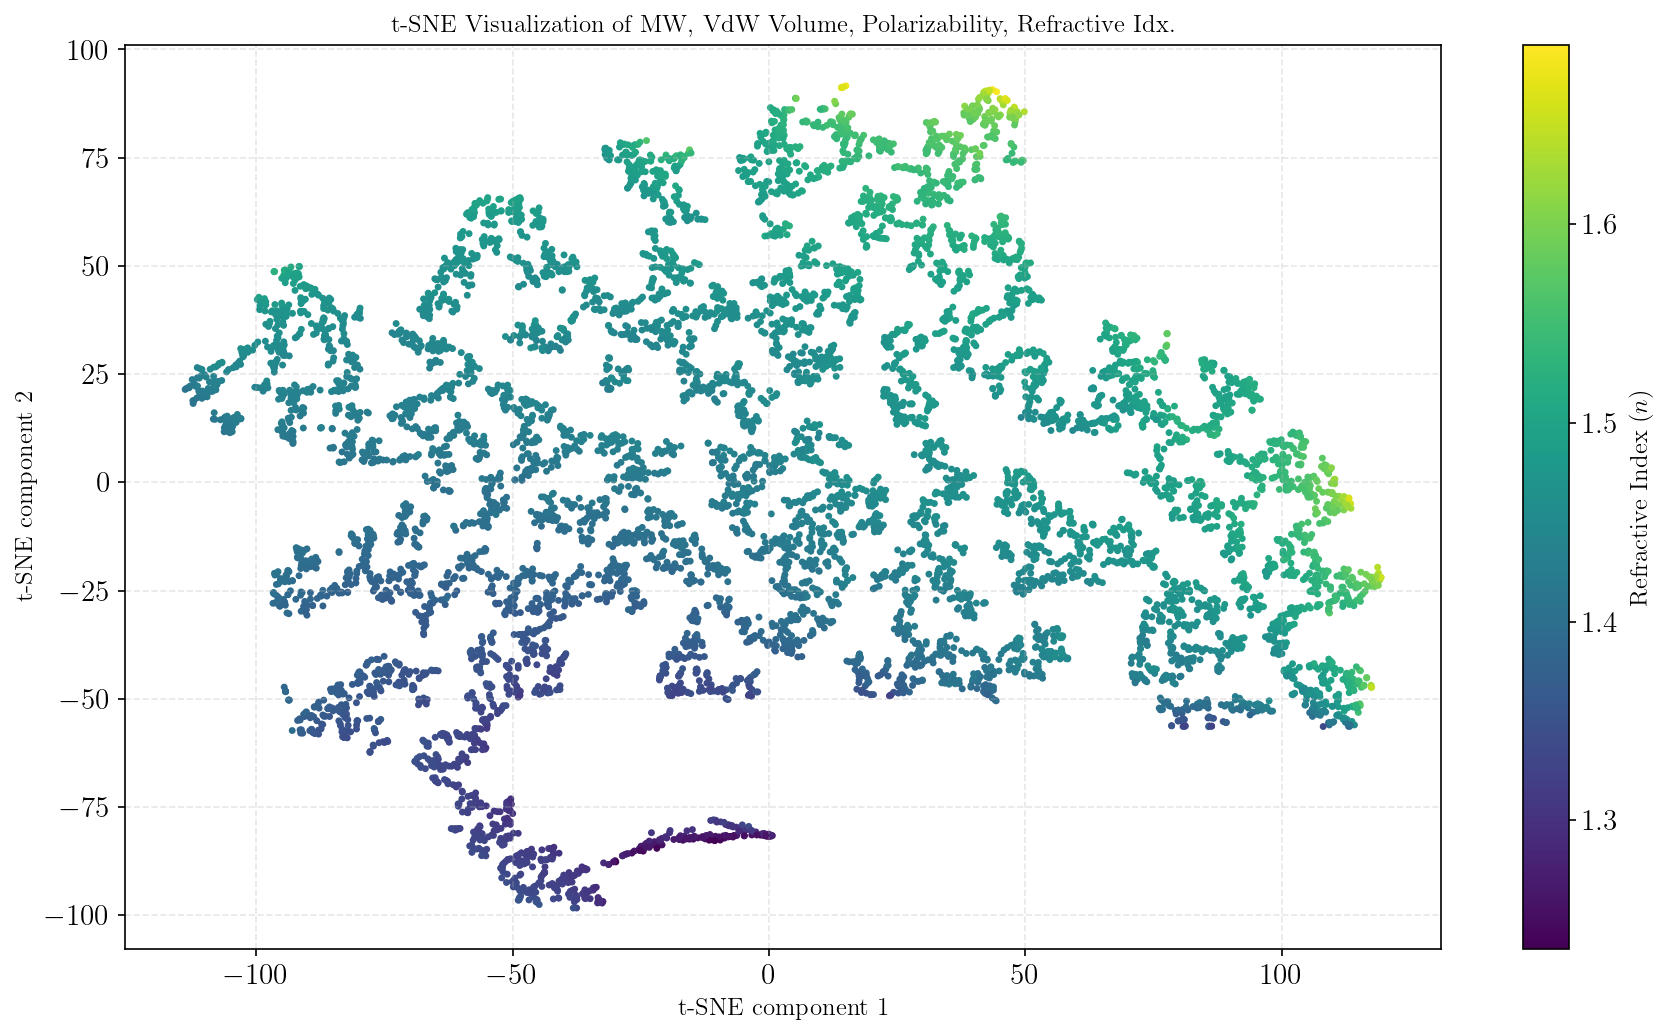

In [5]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 1. Select numeric columns and drop missing values
numeric_cols = df_original.select_dtypes(include=['float64', 'int64']).columns
df_subset = df_original[numeric_cols].dropna()

# 2. Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_subset.drop(columns=['xlogp', 'polararea', 'complexity', 'heavycnt', 'rotbonds']))

# 3. Run t-SNE
# n_components=2 for a 2D plot
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=2000)
X_embedded = tsne.fit_transform(X_scaled)

# 4. Plotting
plt.figure(figsize=(12, 7))
sc = plt.scatter(
    X_embedded[:, 0], 
    X_embedded[:, 1], 
    c=df_subset['refractive_index'], 
    cmap='viridis', 
    #alpha=0.7, 
    edgecolors='none', 
    s=11
)

cbar = plt.colorbar(sc)
cbar.set_label(r'Refractive Index ($n$)', fontsize=12)

plt.title('t-SNE Visualization of MW, VdW Volume, Polarizability, Refractive Idx.', fontsize=12)
plt.xlabel(r't-SNE component 1', fontsize=12)
plt.ylabel(r't-SNE component 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
df_original.columns

Index(['polararea', 'mw', 'smiles', 'xlogp', 'complexity', 'heavycnt',
       'rotbonds', 'static_polarizability', 'vdw_volume', 'refractive_index'],
      dtype='object')

Running t-SNE on 12197 samples with features: ['mw', 'vdw_volume', 'static_polarizability', 'refractive_index']...


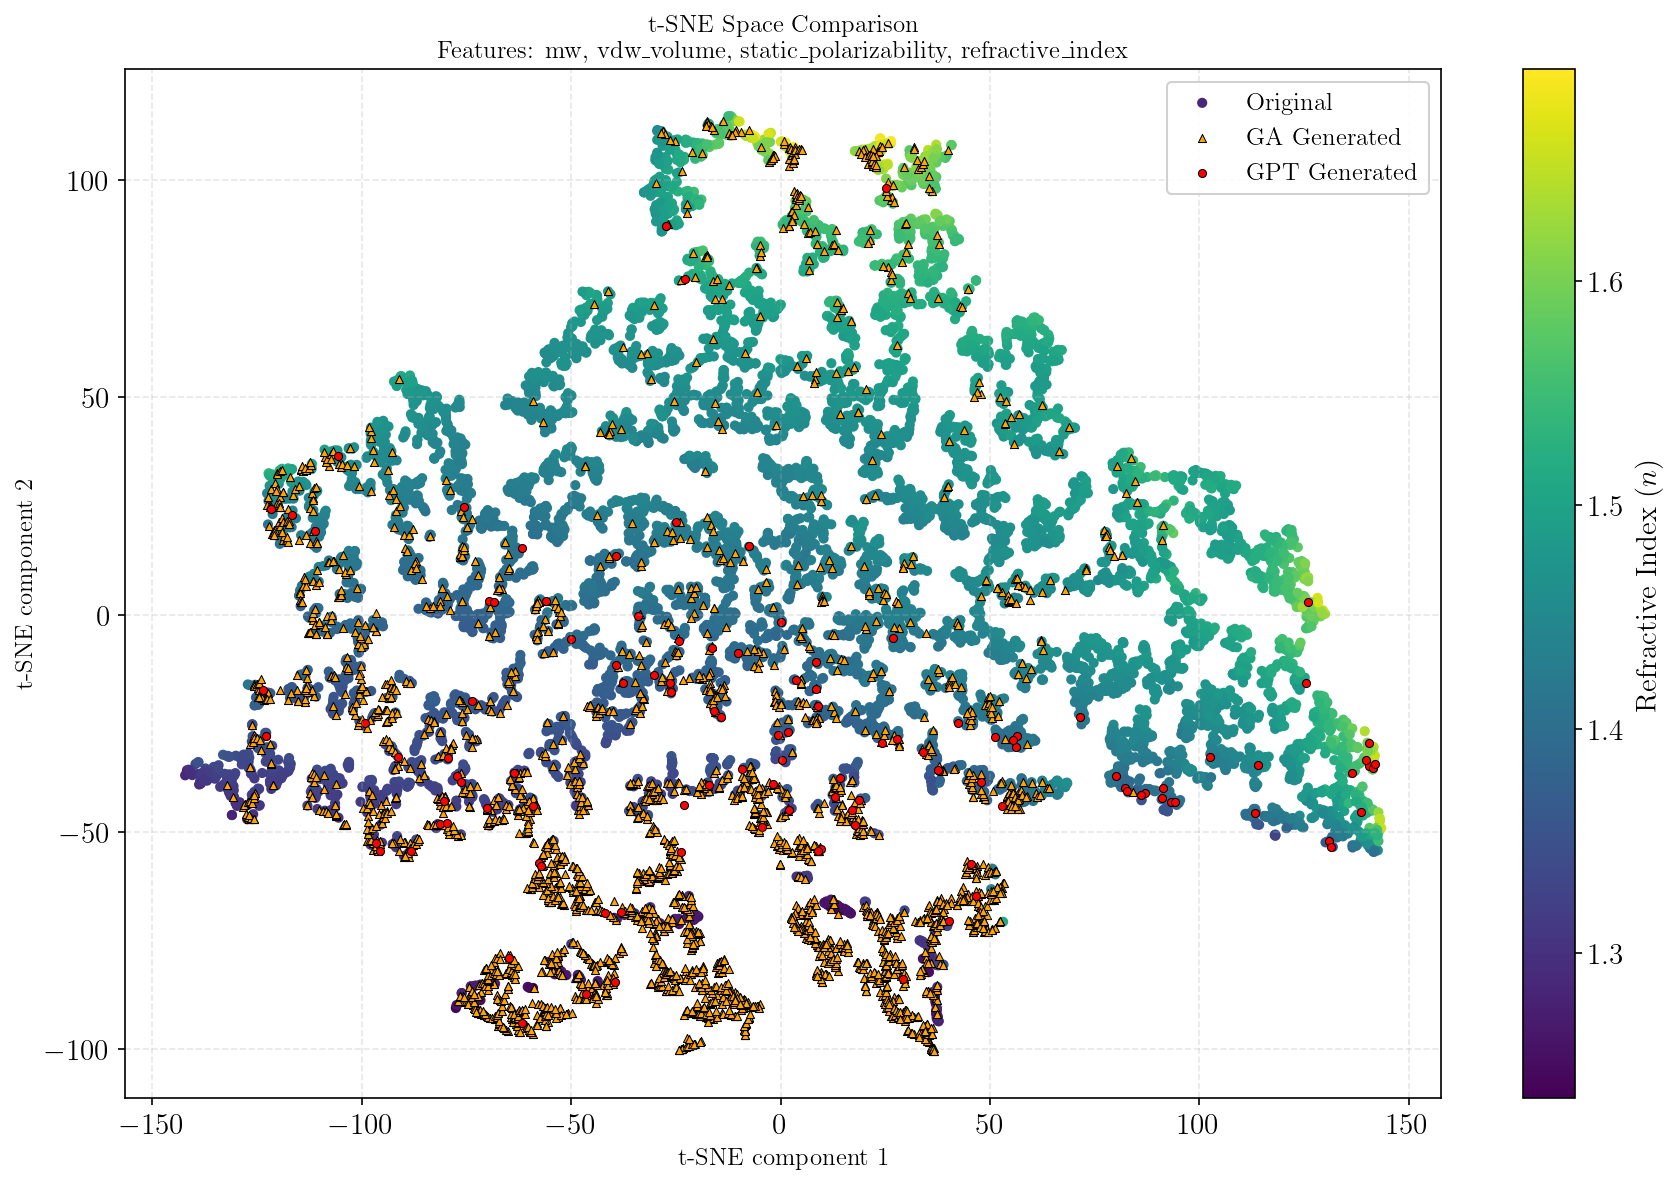

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Prepare Data
# ==========================================

# Define the features we want to use for the embedding
feature_cols = ['mw', 'vdw_volume', 'static_polarizability', 'refractive_index']

# Helper to prepare a dataframe
def prepare_df(df, label, color):
    # Create a copy to avoid SettingWithCopy warnings
    temp = df.copy()
    
    # Handle column naming differences (GA/GPT often have 'pred' suffixes)
    if 'static_polarizability_pred_original' in temp.columns:
        temp = temp.rename(columns={'static_polarizability_pred_original': 'static_polarizability'})
    
    if 'vdw_volume' in temp.columns and 'vdw_volume' in feature_cols:
         pass # It's already there
    elif 'vdw_volume' not in temp.columns and 'vdw_volume' in feature_cols:
        # If missing in one, remove from feature list for fairness
        feature_cols.remove('vdw_volume')
        print(f"Note: 'vdw_volume' missing in {label}, excluding it from t-SNE.")

    # Select features and add metadata
    data = temp[feature_cols].copy()
    data['dataset'] = label
    data['color_code'] = color
    return data.dropna()

# Prepare the three datasets
try:
    df_ga_output = df_ga_output.drop(columns=['static_polarizability'])
    df_gpt_output = df_gpt_output.drop(columns=['static_polarizability'])
except:
    pass

df_orig_prep = prepare_df(df_original, 'Original', 'viridis') # Color placeholder
df_ga_prep   = prepare_df(df_ga_output, 'GA', 'red')
df_gpt_prep  = prepare_df(df_gpt_output, 'GPT', 'red') # Or 'orange' to distinguish

# Combine them
df_combined = pd.concat([df_orig_prep, df_ga_prep, df_gpt_prep], ignore_index=True)

# ==========================================
# 2. Run t-SNE on Combined Data
# ==========================================
print(f"Running t-SNE on {len(df_combined)} samples with features: {feature_cols}...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_combined[feature_cols])

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=2000)
X_embedded = tsne.fit_transform(X_scaled)

# Add coordinates back to dataframe
df_combined['tsne_1'] = X_embedded[:, 0]
df_combined['tsne_2'] = X_embedded[:, 1]

# ==========================================
# 3. Plotting
# ==========================================
plt.figure(figsize=(12, 8))

# --- Plot Original Data (Background) ---
mask_orig = df_combined['dataset'] == 'Original'
sc = plt.scatter(
    df_combined.loc[mask_orig, 'tsne_1'], 
    df_combined.loc[mask_orig, 'tsne_2'], 
    c=df_combined.loc[mask_orig, 'refractive_index'], 
    cmap='viridis', 
    #alpha=0.5, 
    s=15,
    label='Original'
)

# Add Colorbar for the original data
cbar = plt.colorbar(sc)
cbar.set_label(r'Refractive Index ($n$)', fontsize=14)

# --- Plot GA Data (Overlay in Red) ---
mask_ga = df_combined['dataset'] == 'GA'
plt.scatter(
    df_combined.loc[mask_ga, 'tsne_1'], 
    df_combined.loc[mask_ga, 'tsne_2'], 
    c='orange', 
    marker='^',   # Triangle marker to distinguish
    #alpha=0.8, 
    s=15,
    edgecolors='k',
    linewidth=0.5,
    label='GA Generated'
)

# --- Plot GPT Data (Overlay in Red/Magenta) ---
mask_gpt = df_combined['dataset'] == 'GPT'
plt.scatter(
    df_combined.loc[mask_gpt, 'tsne_1'], 
    df_combined.loc[mask_gpt, 'tsne_2'], 
    c='red',      # Or use 'magenta'/'orange' to separate GA vs GPT
    marker='o',   # Circle marker
    #alpha=0.8, 
    s=15,
    edgecolors='k',
    linewidth=0.5,
    label='GPT Generated'
)

# Formatting
plt.title(f't-SNE Space Comparison\nFeatures: {", ".join(feature_cols)}', fontsize=12)
plt.xlabel(r't-SNE component 1', fontsize=12)
plt.ylabel(r't-SNE component 2', fontsize=12)
plt.legend(loc='upper right', fontsize=12, frameon=True, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

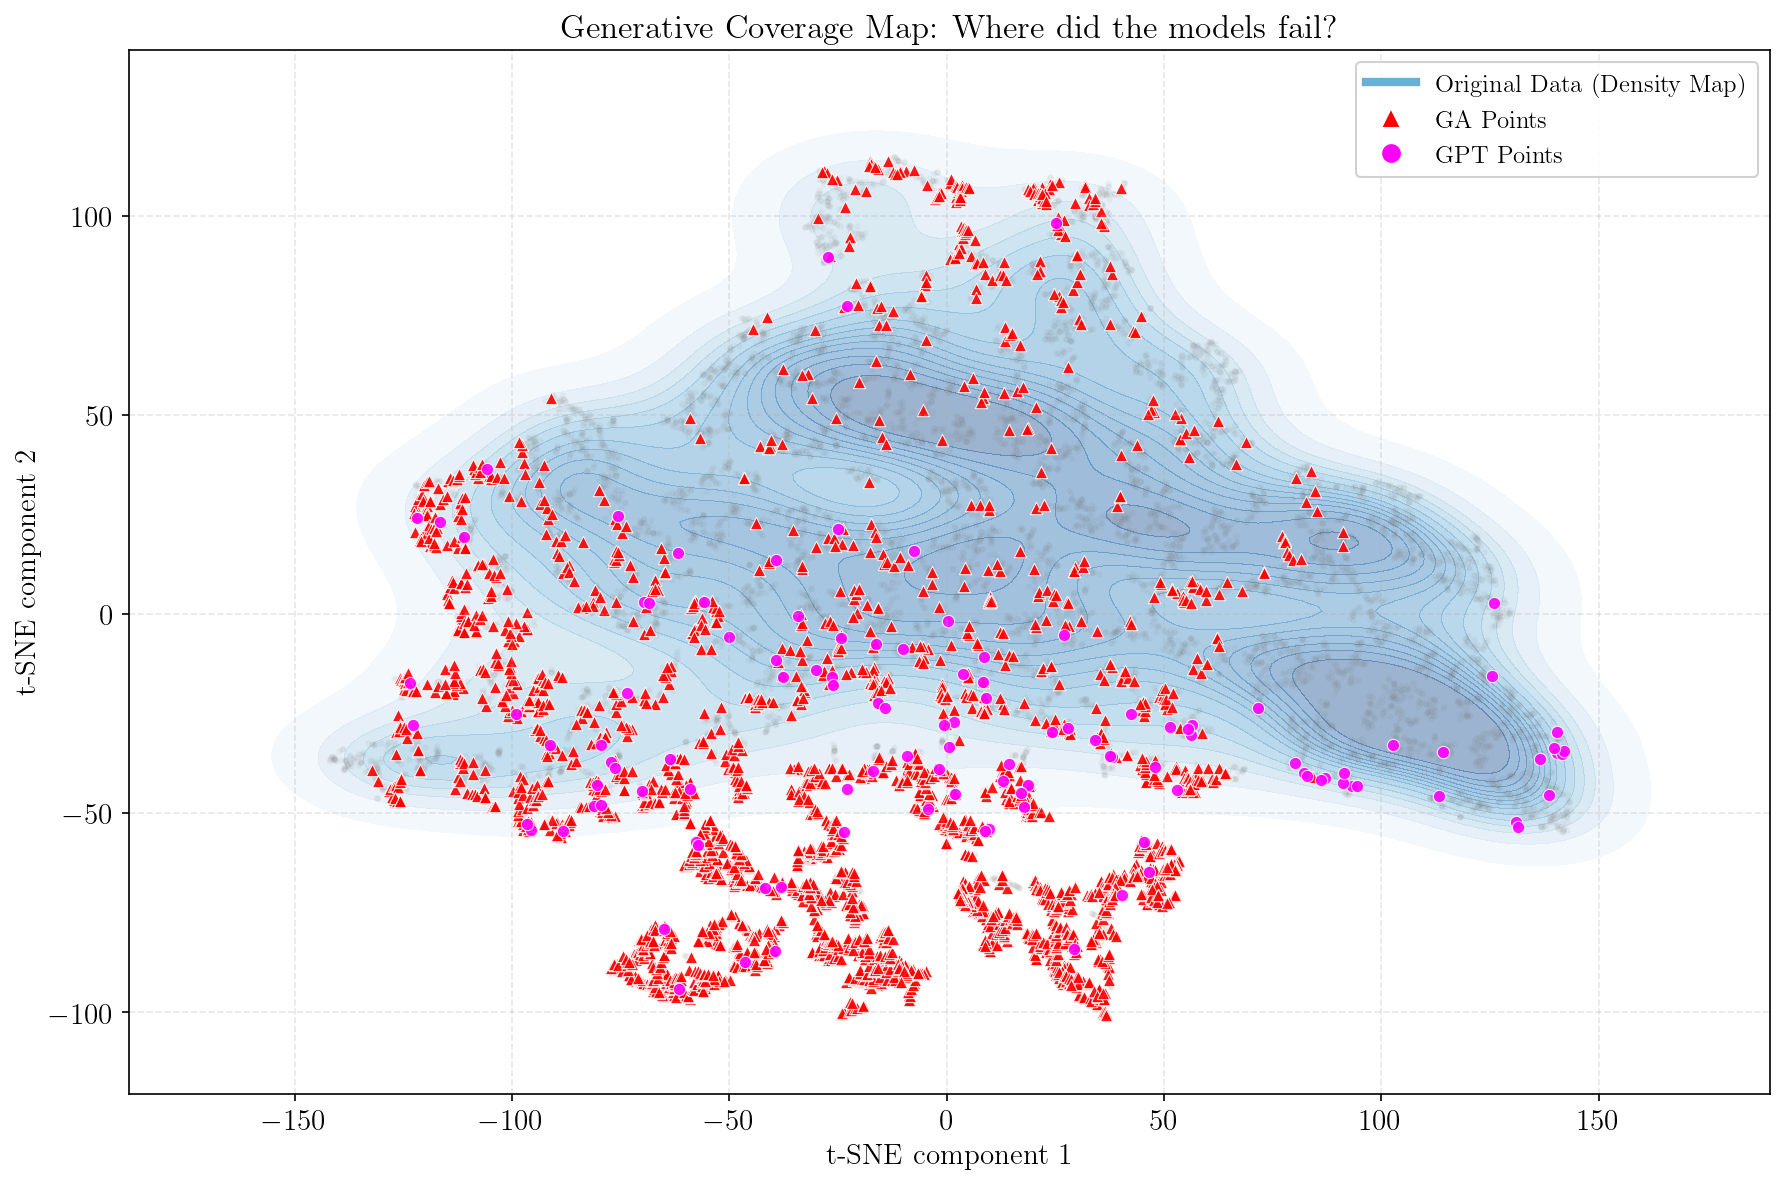

In [ ]:
import seaborn as sns

# Reuse the 'df_combined' and masks from the previous step
plt.figure(figsize=(12, 8))

# ==========================================
# 1. The "Target Territory" (Original Data Density)
# ==========================================
# We plot the Kernel Density Estimation (KDE) of the Original data.
# Darker blue = More original data exists here.
# Any dark blue area WITHOUT red/magenta points is a "Missed Region".
sns.kdeplot(
    x=df_combined.loc[mask_orig, 'tsne_1'],
    y=df_combined.loc[mask_orig, 'tsne_2'],
    fill=True, 
    cmap="Blues",       # Blue background to contrast with Red/Magenta points
    levels=15,          # More levels = detailed topology
    thresh=0.05,        # Threshold to cut off very low density areas (outliers)
    alpha=0.4,          # Transparency so grid lines show through
    label='Original Distribution Density'
)

# Optional: Add a faint scatter of original points to show exact RI values
# (Kept very faint so they don't visually compete with the generated points)
plt.scatter(
    df_combined.loc[mask_orig, 'tsne_1'], 
    df_combined.loc[mask_orig, 'tsne_2'], 
    c='gray',           # Neutral color
    alpha=0.05,         # Very faint
    s=5
)

# ==========================================
# 2. The "Explored Areas" (Generated Data)
# ==========================================

# GA Data
plt.scatter(
    df_combined.loc[mask_ga, 'tsne_1'], 
    df_combined.loc[mask_ga, 'tsne_2'], 
    c='red', 
    marker='^', 
    alpha=0.9, 
    s=35,
    edgecolors='white', # White edge helps them pop against the blue map
    linewidth=0.5,
    label='GA Generated'
)

# GPT Data
plt.scatter(
    df_combined.loc[mask_gpt, 'tsne_1'], 
    df_combined.loc[mask_gpt, 'tsne_2'], 
    c='magenta', 
    marker='o', 
    alpha=0.9, 
    s=35,
    edgecolors='white',
    linewidth=0.5,
    label='GPT Generated'
)

# ==========================================
# 3. Formatting
# ==========================================
plt.title(r'Generative Coverage Map: Where did the models fail?', fontsize=12)
plt.xlabel(r't-SNE component 1', fontsize=12)
plt.ylabel(r't-SNE component 2', fontsize=12)

# Custom Legend to explain the map
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#6baed6', lw=4, label='Original Data (Density Map)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='red', markersize=10, label='GA Points'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='magenta', markersize=10, label='GPT Points')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12, framealpha=0.9)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()